<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


##### Import Necessary Modules:


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [2]:
# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [3]:
## Write your code here
# i have to display basic information and summary statistics of the dataset
# Display basic information about the dataset
print(df.info())
# Display summary statistics of the dataset
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29393.000000    29411.000000    29450.000000     29448.00000   
mean         7.522140       10.060857       24.343232        22.96

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
## Write your code here
# identify the missing values for all columns in the dataset
# Check for missing values in the dataset
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)


AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
MainBranch                        0
Age                               0
Employment                        0
Check                             0
ResponseId                        0
Length: 114, dtype: int64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



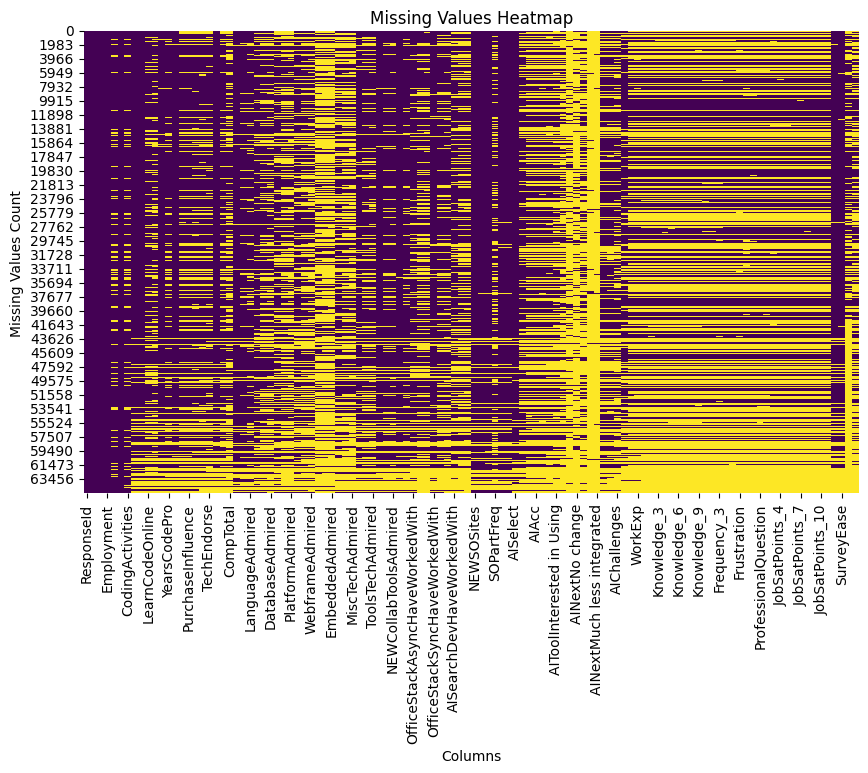

In [10]:
## Write your code here
# i have to visualize the missing values in the dataset using a heatmap
# Visualize missing values using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Missing Values Count')
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [13]:
## Write your code here
# count the number of missing values in the 'EmbeddedAdmired' column
missing_embedded_admired = df['EmbeddedAdmired'].isnull().sum()
print(f"Missing values in 'EmbeddedAdmired' column: {missing_embedded_admired}")

Missing values in 'EmbeddedAdmired' column: 48704


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [14]:
## Write your code here
# Most frequent value in the 'EmbeddedAdmired' column
most_frequent_value = df['EmbeddedAdmired'].mode()[0]
print(f"Most frequent value in 'EmbeddedAdmired' column: {most_frequent_value}")

Most frequent value in 'EmbeddedAdmired' column: Rasberry Pi


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [15]:
## Write your code here
#  i have to fill the missing values in the 'EmbeddedAdmired' column with the most frequent value
# Fill missing values in 'EmbeddedAdmired' column with the most frequent value
df['EmbeddedAdmired'] = df['EmbeddedAdmired'].fillna(most_frequent_value)

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


EmbeddedAdmired
Rasberry Pi                                                       52150
Arduino;Rasberry Pi                                                1402
Cargo                                                              1355
Arduino                                                            1215
GNU GCC                                                             810
                                                                  ...  
CMake;Meson;QMake                                                     1
Arduino;Micronaut;PlatformIO;Rasberry Pi                              1
Boost.Test;build2;cppunit;GNU GCC;LLVM's Clang;MSVC;PlatformIO        1
Arduino;GNU GCC;Micronaut;Rasberry Pi                                 1
Boost.Test;cppunit;CUTE;MSVC;Ninja;PlatformIO;ZMK                     1
Name: count, Length: 1053, dtype: int64


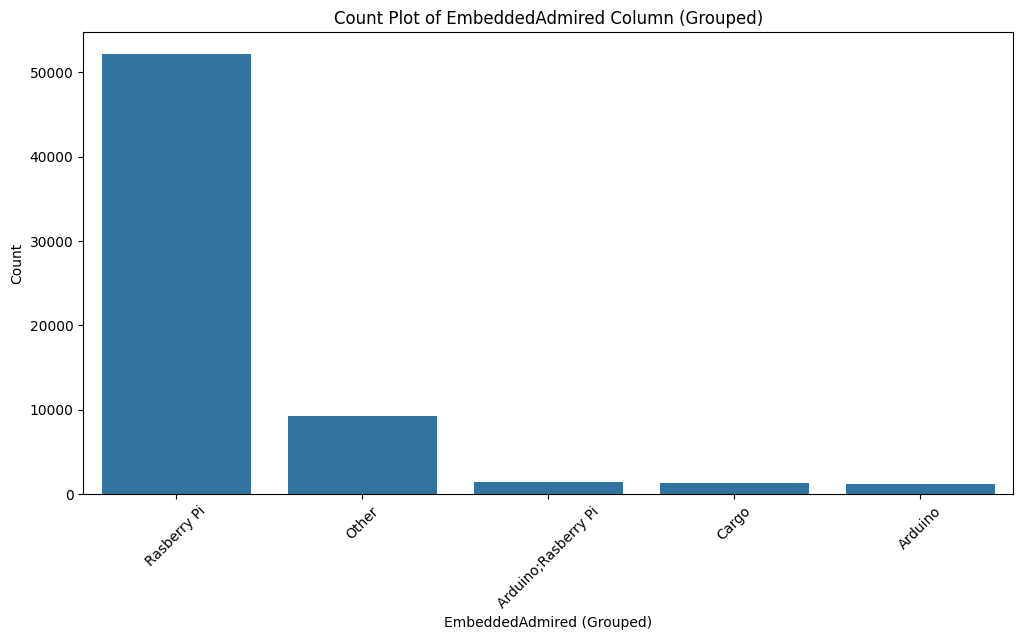

In [39]:
## Write your code here
# i have to visualize the imputed data in the 'EmbeddedAdmired' column using a count plot
# I need to make grouping of values as there are 65000 values in the 'EmbeddedAdmired' column
counts = df['EmbeddedAdmired'].value_counts()
print(counts)
# grouping values based on value counts and values less than 1000 will be grouped as 'Other' and null values have own group named null
df['EmbeddedAdmired_grouped'] = df['EmbeddedAdmired'].apply(lambda x: x if counts[x] >= 1000 else 'Other')
# Visualize the imputed data in the 'EmbeddedAdmired' column using a count plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='EmbeddedAdmired_grouped', order=df['EmbeddedAdmired_grouped'].value_counts().index)
plt.title('Count Plot of EmbeddedAdmired Column (Grouped)')
plt.xlabel('EmbeddedAdmired (Grouped)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()















### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
